In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## 1. Load data from csv

In [2]:
original_file_size = 1900003732

df_linux = pd.read_csv('../results/exp1_linux.csv')
df_linux['os'] = 'linux'

df_windows = pd.read_csv('../results/exp1_windows.csv')
df_windows['os'] = 'windows'

df = pd.concat([df_linux, df_windows], ignore_index=True)

# Remove not correct configurations
df = df[df['is_correct'] == 1]

# Add "None" compressor - doing nothing
df = pd.concat([df, pd.DataFrame(
            [
                {
                    'compressor': 'None',
                    'os': 'linux',
                    'level': 0,
                    'is_correct': 1,
                    'compressed_size': original_file_size,
                    'compression_time': 0.0,
                    'decompression_time': 0.0,
                    'avg_cpu_compression': 0.0,
                    'avg_cpu_decompression': 0.0,
                    'compression_ratio': 1.0
                },
                {
                    'compressor': 'None',
                    'os': 'windows',
                    'level': 0,
                    'is_correct': 1,
                    'compressed_size': original_file_size,
                    'compression_time': 0.0,
                    'decompression_time': 0.0,
                    'avg_cpu_compression': 0.0,
                    'avg_cpu_decompression': 0.0,
                    'compression_ratio': 1.0
                }
            ]
        )
    ], 
    ignore_index=True
)

## 2. Plot a compression ratio chart for each compressor

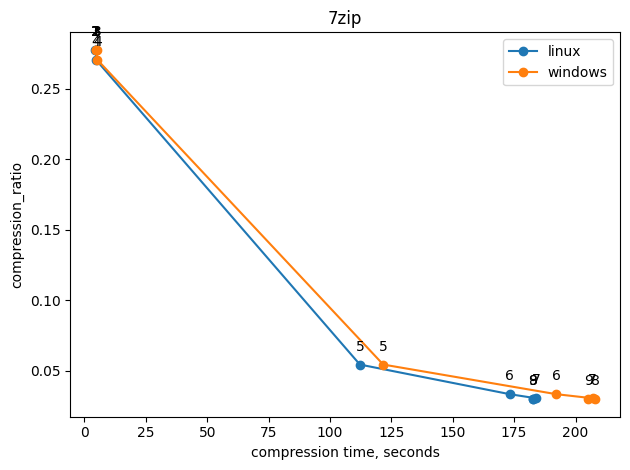

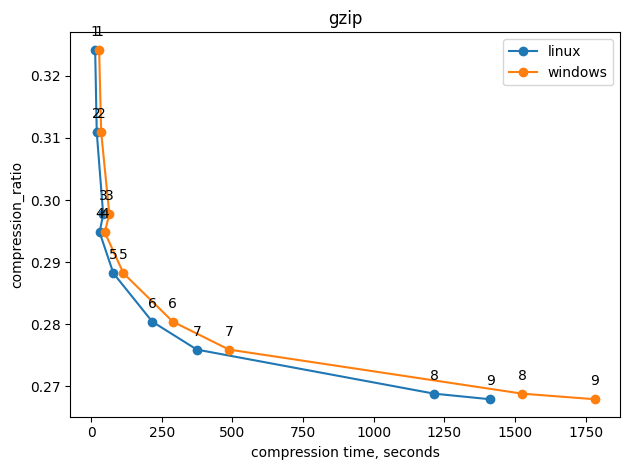

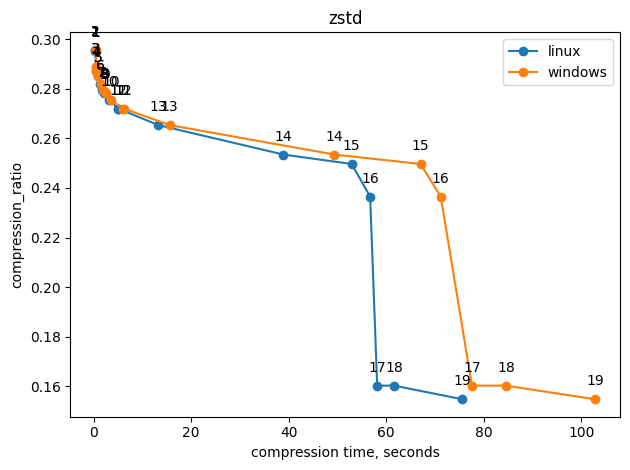

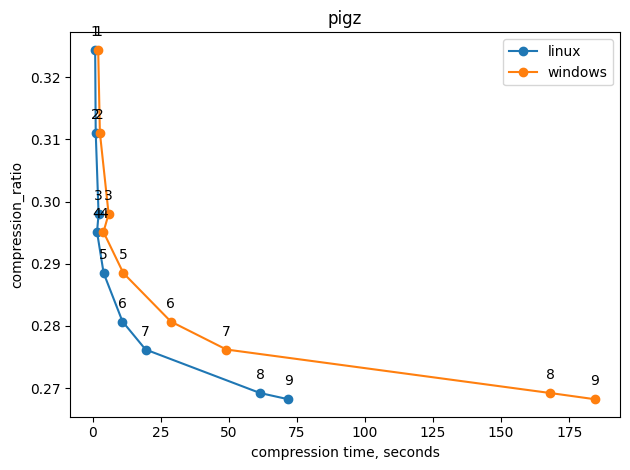

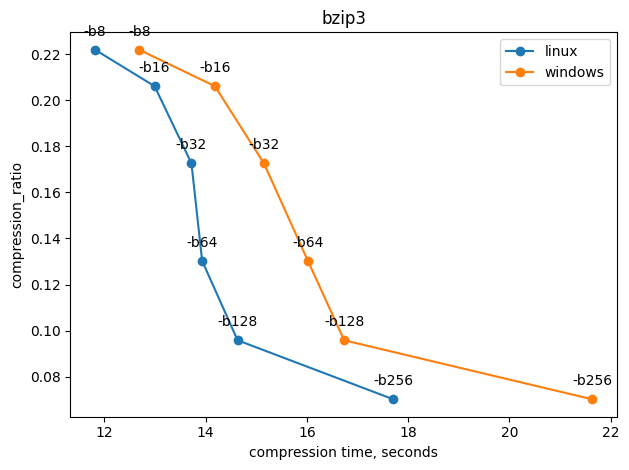

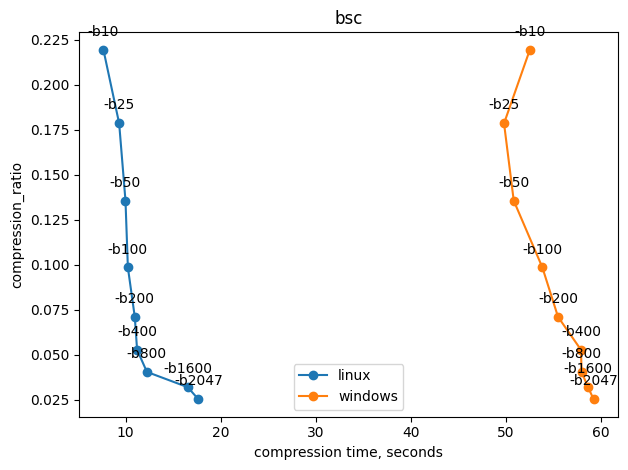

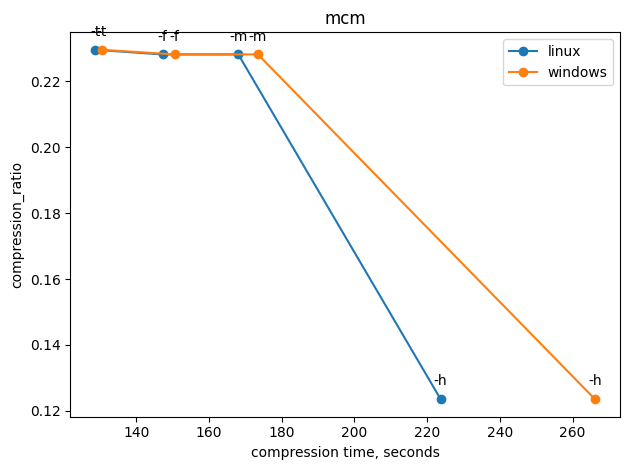

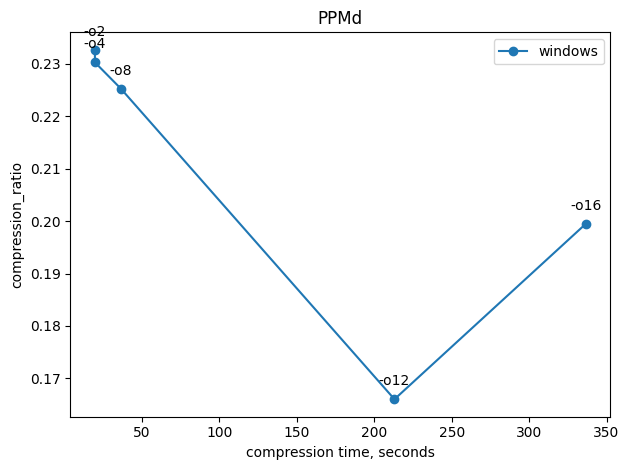

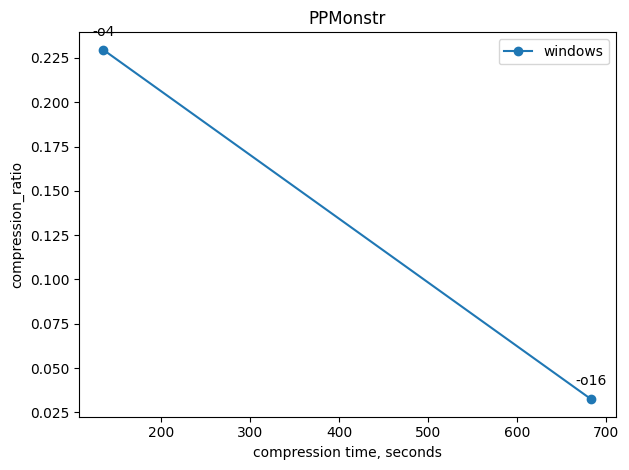

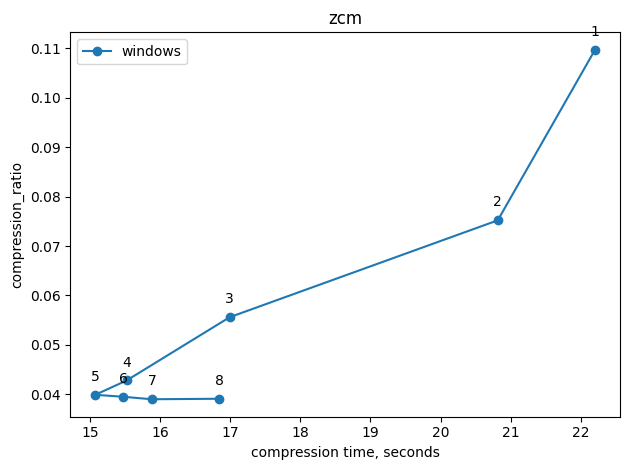

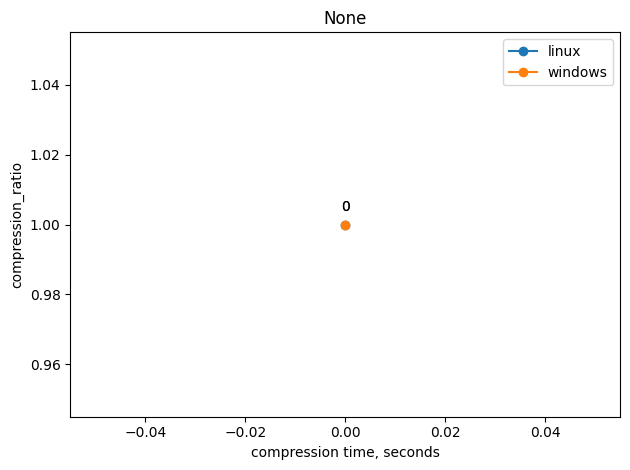

In [ ]:
os.makedirs('plots', exist_ok=True)

for compressor in df['compressor'].unique():
    comp_df = df[df['compressor'] == compressor]
    
    plt.figure()
    for os_name in comp_df['os'].unique():
        os_df = comp_df[comp_df['os'] == os_name]
        
        plt.plot(
            os_df['compression_time'], 
            os_df['compression_ratio'], 
            marker='o',
            label=os_name
        )
        
        for idx, row in os_df.iterrows():
            plt.annotate(
                str(row['level']),
                (row['compression_time'], row['compression_ratio']),
                textcoords="offset points",
                xytext=(0,10),
                ha='center'
            )
            
    plt.xlabel('compression time, seconds')
    plt.ylabel('compression_ratio')
    plt.title(compressor)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join("plots", f'{compressor.lower()}.svg'))
    plt.show()

## 3. Calculate cost for each configuration

In [4]:
# https://aws.amazon.com/ec2/pricing/on-demand/
# c6g.8xlarge - $1.088 / hour
price_per_hour = 1.088

# https://aws.amazon.com/s3/pricing/
# S3 One Zone - Infrequent Access - $0.01 / (GB * month)
# suppose we keep data for 2 years
price_per_gb = 0.24

price_per_byte = price_per_gb / (1024**3)
price_per_second = price_per_hour / 3600

# Scaling factor to rescale data from the original size to 1 TiB
tb_in_bytes = 1024**4
scale = tb_in_bytes / original_file_size

df['compute_cost_per_tb'] = (df['compression_time'] * price_per_second) * scale
df['storage_cost_per_tb'] = (df['compressed_size'] * price_per_byte) * scale
df['total_cost_per_tb'] = df['compute_cost_per_tb'] + df['storage_cost_per_tb']

optimal_levels = df.loc[df.groupby(['compressor', 'os'])['total_cost_per_tb'].idxmin()]

## 4. Table ranking

In [5]:
# Sort to create the full ranking
ranking = df.sort_values('total_cost_per_tb').reset_index(drop=True)

# Select relevant columns for display
cols_to_show = [
    'compressor', 'os', 'level',
    'total_cost_per_tb', 'compute_cost_per_tb', 'storage_cost_per_tb',
    'compression_ratio', 'compression_time', 'decompression_time', 'avg_cpu_compression', 'avg_cpu_decompression'
]

ranking_disp = ranking[cols_to_show].copy()
ranking_disp.index = ranking_disp.index + 1

rename_map = {
    'compressor': 'Compressor',
    'os': 'OS',
    'level': 'Level',
    'total_cost_per_tb': 'Total cost/TB',
    'compute_cost_per_tb': 'Compute cost/TB',
    'storage_cost_per_tb': 'Storage cost/TB',
    'compression_ratio': 'Compression ratio',
    'compression_time': 'Comp time [s]',
    'decompression_time': 'Decomp time [s]',
    'avg_cpu_compression': 'Avg CPU comp [%]',
    'avg_cpu_decompression': 'Avg CPU decomp [%]'
}
ranking_disp = ranking_disp.rename(columns=rename_map)

def highlight_best_compressor(data):
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    first_idx = data.drop_duplicates(['Compressor', 'OS']).index
    styles.loc[first_idx, :] = 'background-color: lightgreen; color: black'
    return styles

ranking_styled_df = ranking_disp.style.apply(highlight_best_compressor, axis=None).format(precision=2)

with open("plots/ranking.html", "w", encoding="utf-8") as f:
    f.write(ranking_styled_df.to_html())

ranking_styled_df

,Compressor,OS,Level,Total cost/TB,Compute cost/TB,Storage cost/TB,Compression ratio,Comp time [s],Decomp time [s],Avg CPU comp [%],Avg CPU decomp [%]
1,bsc,linux,-b2047,9.29,3.09,6.20,0.03,17.65,7.67,17.50,45.32
2,bsc,linux,-b1600,10.74,2.89,7.85,0.03,16.53,7.87,19.34,43.93
3,bsc,linux,-b800,12.06,2.14,9.92,0.04,12.23,4.69,36.41,56.32
4,zcm,windows,7,12.37,2.78,9.60,0.04,15.88,15.55,85.23,86.42
5,zcm,windows,6,12.41,2.71,9.71,0.04,15.47,14.81,87.00,83.25
6,zcm,windows,5,12.45,2.64,9.81,0.04,15.08,14.77,85.00,78.67
7,zcm,windows,8,12.55,2.95,9.60,0.04,16.85,16.35,89.54,85.62
8,zcm,windows,4,13.23,2.71,10.52,0.04,15.52,15.01,85.42,86.58
9,bsc,linux,-b400,14.91,1.96,12.95,0.05,11.20,3.15,49.98,59.46
10,bsc,windows,-b2047,16.57,10.37,6.20,0.03,59.27,25.36,0.35,0.58


## 5. Generate table ranking with best configurations

In [7]:
best_cols = ['Compressor', 'OS', 'Level', 'Total cost/TB', 'Compute cost/TB', 'Storage cost/TB', 'Avg CPU comp [%]', 'Avg CPU decomp [%]']
best_disp = ranking_disp.drop_duplicates(['Compressor', 'OS'])[best_cols]

best_styled = best_disp.style.format(precision=2)

with open("plots/ranking_best.html", "w", encoding="utf-8") as f:
    f.write(best_styled.to_html())

best_styled

,Compressor,OS,Level,Total cost/TB,Compute cost/TB,Storage cost/TB,Avg CPU comp [%],Avg CPU decomp [%]
1,bsc,linux,-b2047,9.29,3.09,6.20,17.50,45.32
4,zcm,windows,7,12.37,2.78,9.60,85.23,86.42
10,bsc,windows,-b2047,16.57,10.37,6.20,0.35,0.58
15,bzip3,linux,-b256,20.35,3.10,17.25,24.65,24.08
16,bzip3,windows,-b256,21.04,3.78,17.25,22.41,31.56
24,7zip,linux,5,32.97,19.62,13.36,49.18,12.44
27,7zip,windows,5,34.64,21.28,13.36,84.45,29.00
42,zstd,linux,17,49.55,10.17,39.38,86.05,4.15
47,zstd,windows,17,52.95,13.57,39.38,93.35,2.00
54,PPMd,windows,-o4,60.02,3.43,56.59,0.38,1.11
